# Section 16.7

In [ ]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test_new, y_train, y_test_new = train_test_split(
    X_train, y_train, test_size=0.75, random_state=42)


In [ ]:
X_train.shape

(15000, 28, 28)

In [ ]:
y_train.shape

(15000,)

In [ ]:
X_test.shape

(10000, 28, 28)

In [ ]:
y_test.shape

(10000,)

In [ ]:
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
sns.set(font_scale=2)

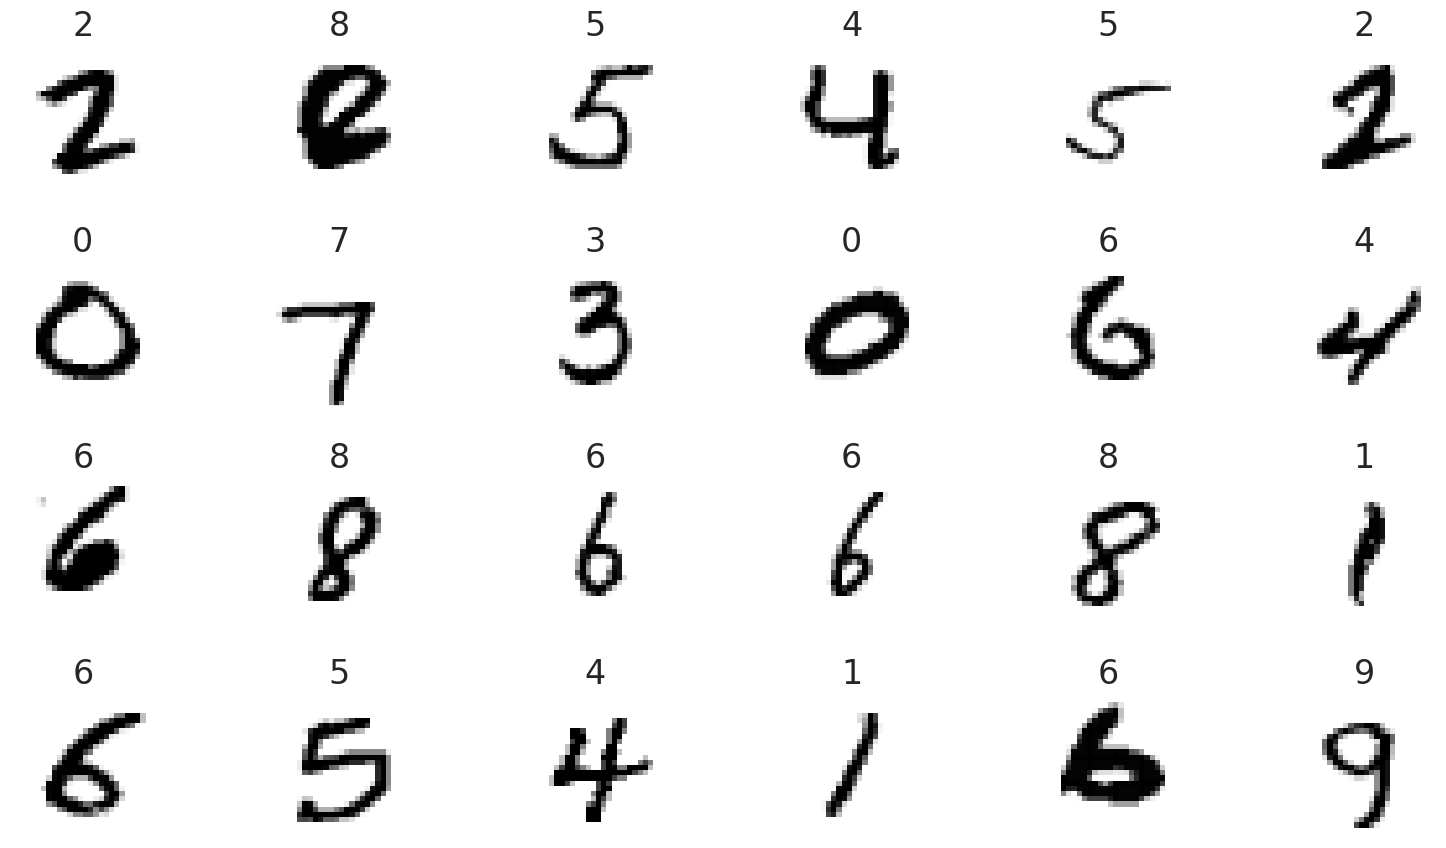

In [ ]:
import numpy as np
index = np.random.choice(np.arange(len(X_train)), 24, replace=False)
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for item in zip(axes.ravel(), X_train, y_train):
    axes, image, target = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])  # remove x-axis tick marks
    axes.set_yticks([])  # remove y-axis tick marks
    axes.set_title(target)
plt.tight_layout()

In [ ]:
X_train = X_train.reshape((15000, 28, 28, 1))

In [ ]:
X_train.shape

(15000, 28, 28, 1)

In [ ]:
X_train = X_train.astype('float32') / 255

In [ ]:
X_test = X_test.reshape((10000, 28, 28, 1))

In [ ]:
X_test.shape

(10000, 28, 28, 1)

In [ ]:
X_test = X_test.astype('float32') / 255

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
y_train = to_categorical(y_train)

In [ ]:
y_train.shape

(15000, 10)

In [ ]:
y_train[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
y_test = to_categorical(y_test)

In [ ]:
y_test.shape

(10000, 10)

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
cnn = Sequential()

In [ ]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

In [ ]:
cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
               input_shape=(28, 28, 1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.add(MaxPooling2D(pool_size=(2, 2)))

In [ ]:
cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))

In [ ]:
cnn.add(MaxPooling2D(pool_size=(2, 2)))

In [ ]:
cnn.add(Flatten())

In [ ]:
cnn.add(Dense(units=128, activation='relu'))

In [ ]:
cnn.add(Dense(units=10, activation='softmax'))

In [ ]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

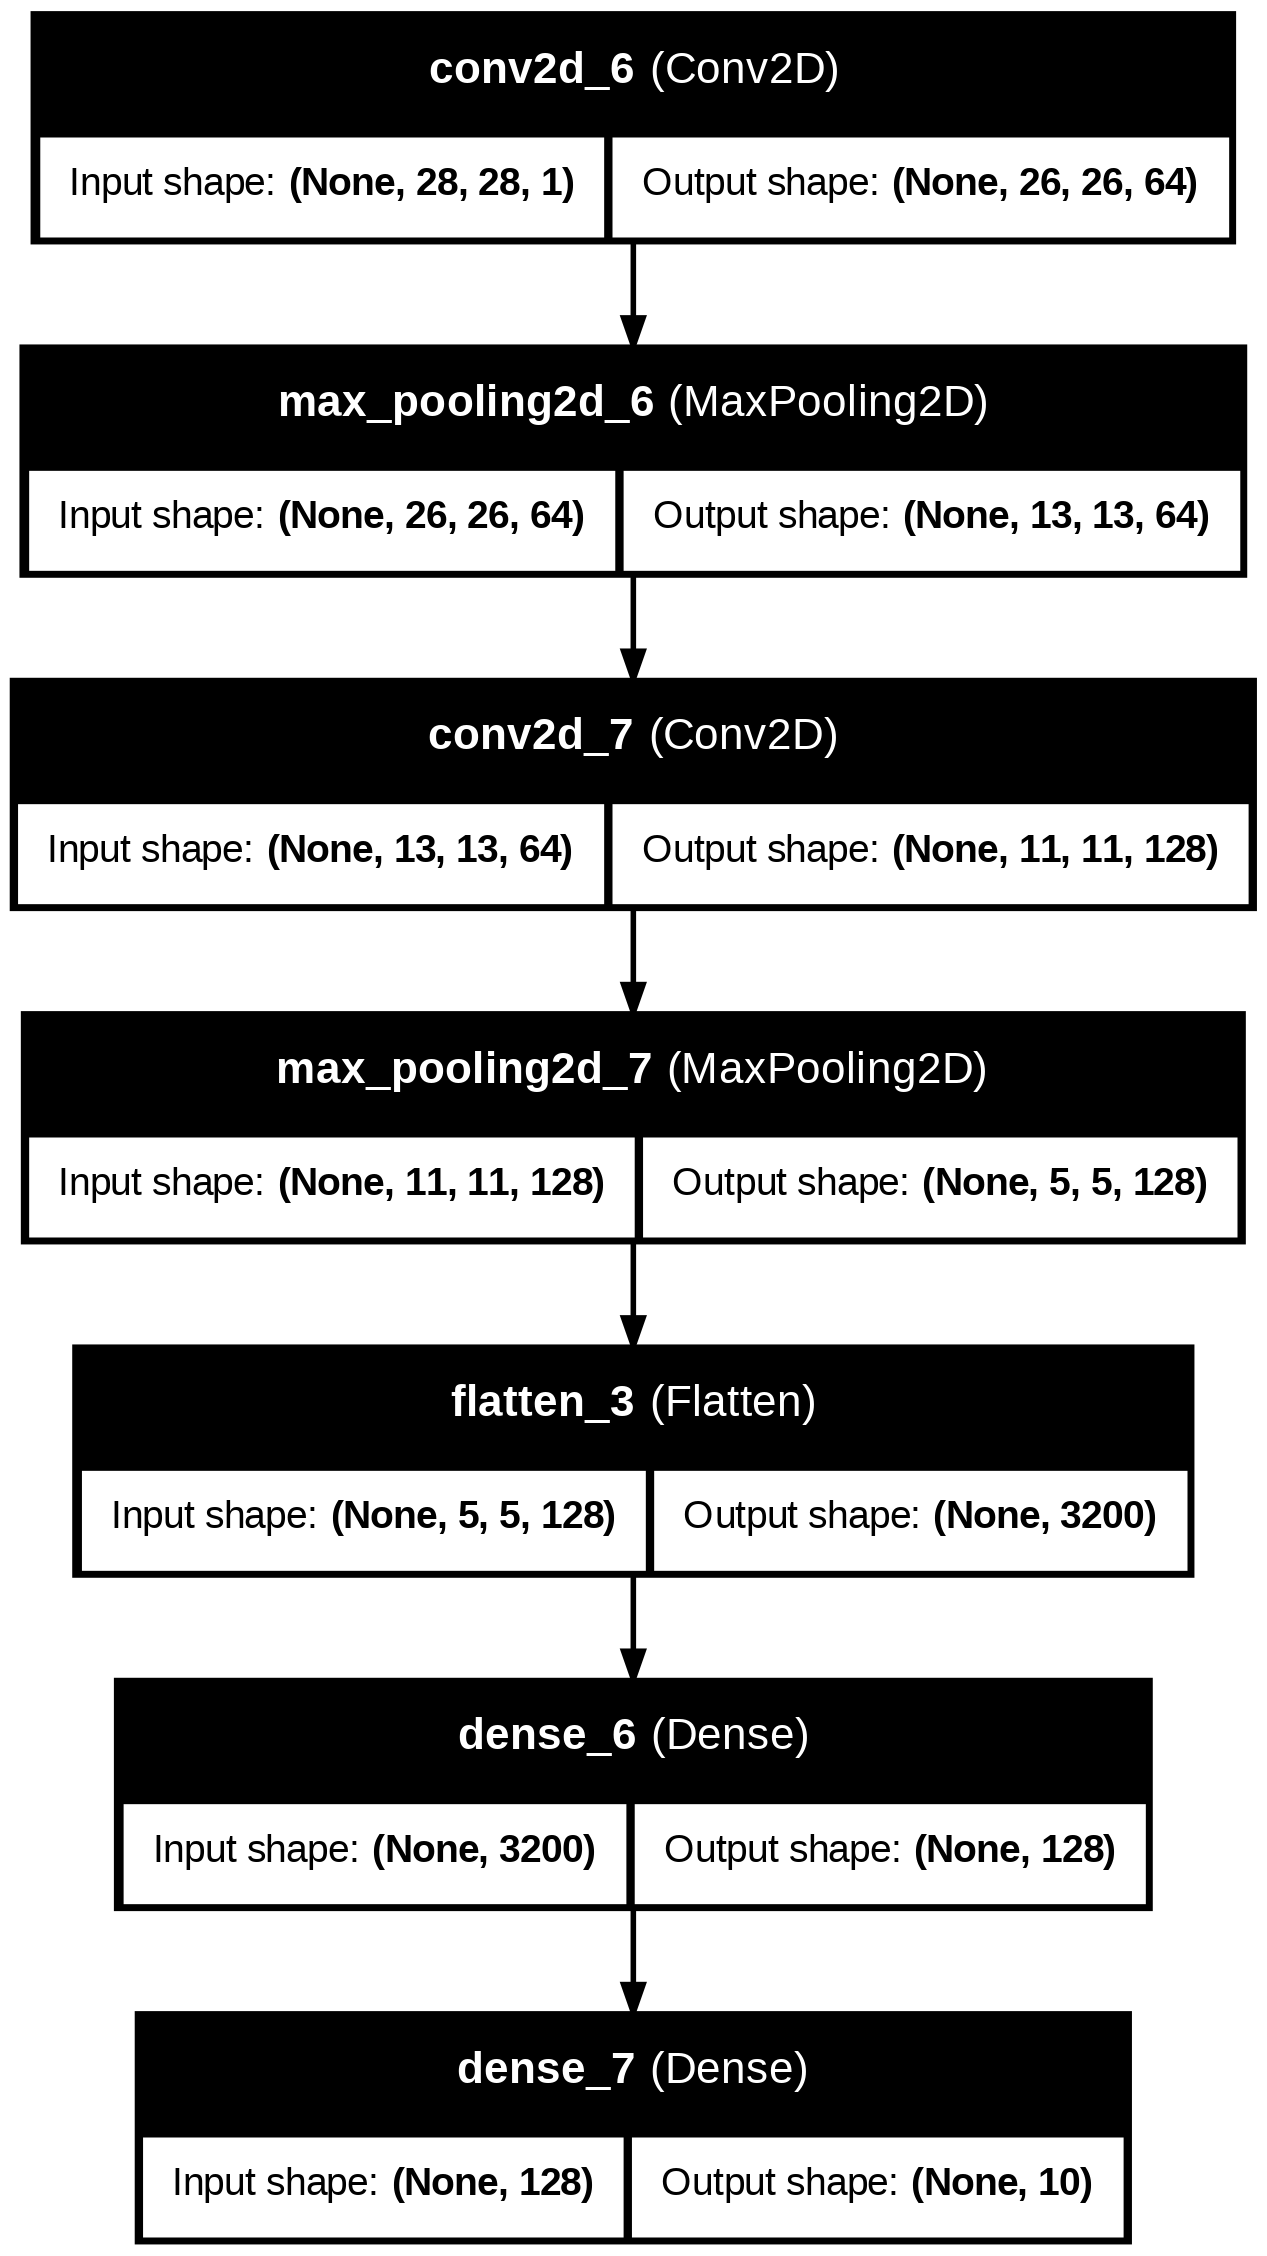

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(cnn, to_file='convnet.png', show_shapes=True,
           show_layer_names=True)
Image(filename='convnet.png')

In [ ]:
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7673 - loss: 0.7322 - val_accuracy: 0.9653 - val_loss: 0.1104
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.0886 - val_accuracy: 0.9753 - val_loss: 0.0709
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9854 - loss: 0.0499 - val_accuracy: 0.9767 - val_loss: 0.0710
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9890 - loss: 0.0334 - val_accuracy: 0.9767 - val_loss: 0.0680
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.0309 - val_accuracy: 0.9767 - val_loss: 0.0656


In [ ]:
loss, accuracy = cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9795 - loss: 0.0698


In [ ]:
loss

0.05796896293759346

In [ ]:
accuracy

0.9825999736785889

In [ ]:
predictions = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [ ]:
for index, probability in enumerate(predictions[0]):
    print(f'{index}: {probability:.10%}')

0: 0.0000000102%
1: 0.0000000427%
2: 0.0000021821%
3: 0.0000991547%
4: 0.0000000000%
5: 0.0000000016%
6: 0.0000000000%
7: 99.9998927116%
8: 0.0000004280%
9: 0.0000005105%


In [ ]:
images = X_test.reshape((10000, 28, 28))
incorrect_predictions = []

for i, (p, e) in enumerate(zip(predictions, y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)

    if predicted != expected:
        incorrect_predictions.append((i, images[i], predicted, expected))

In [ ]:
len(incorrect_predictions)

174

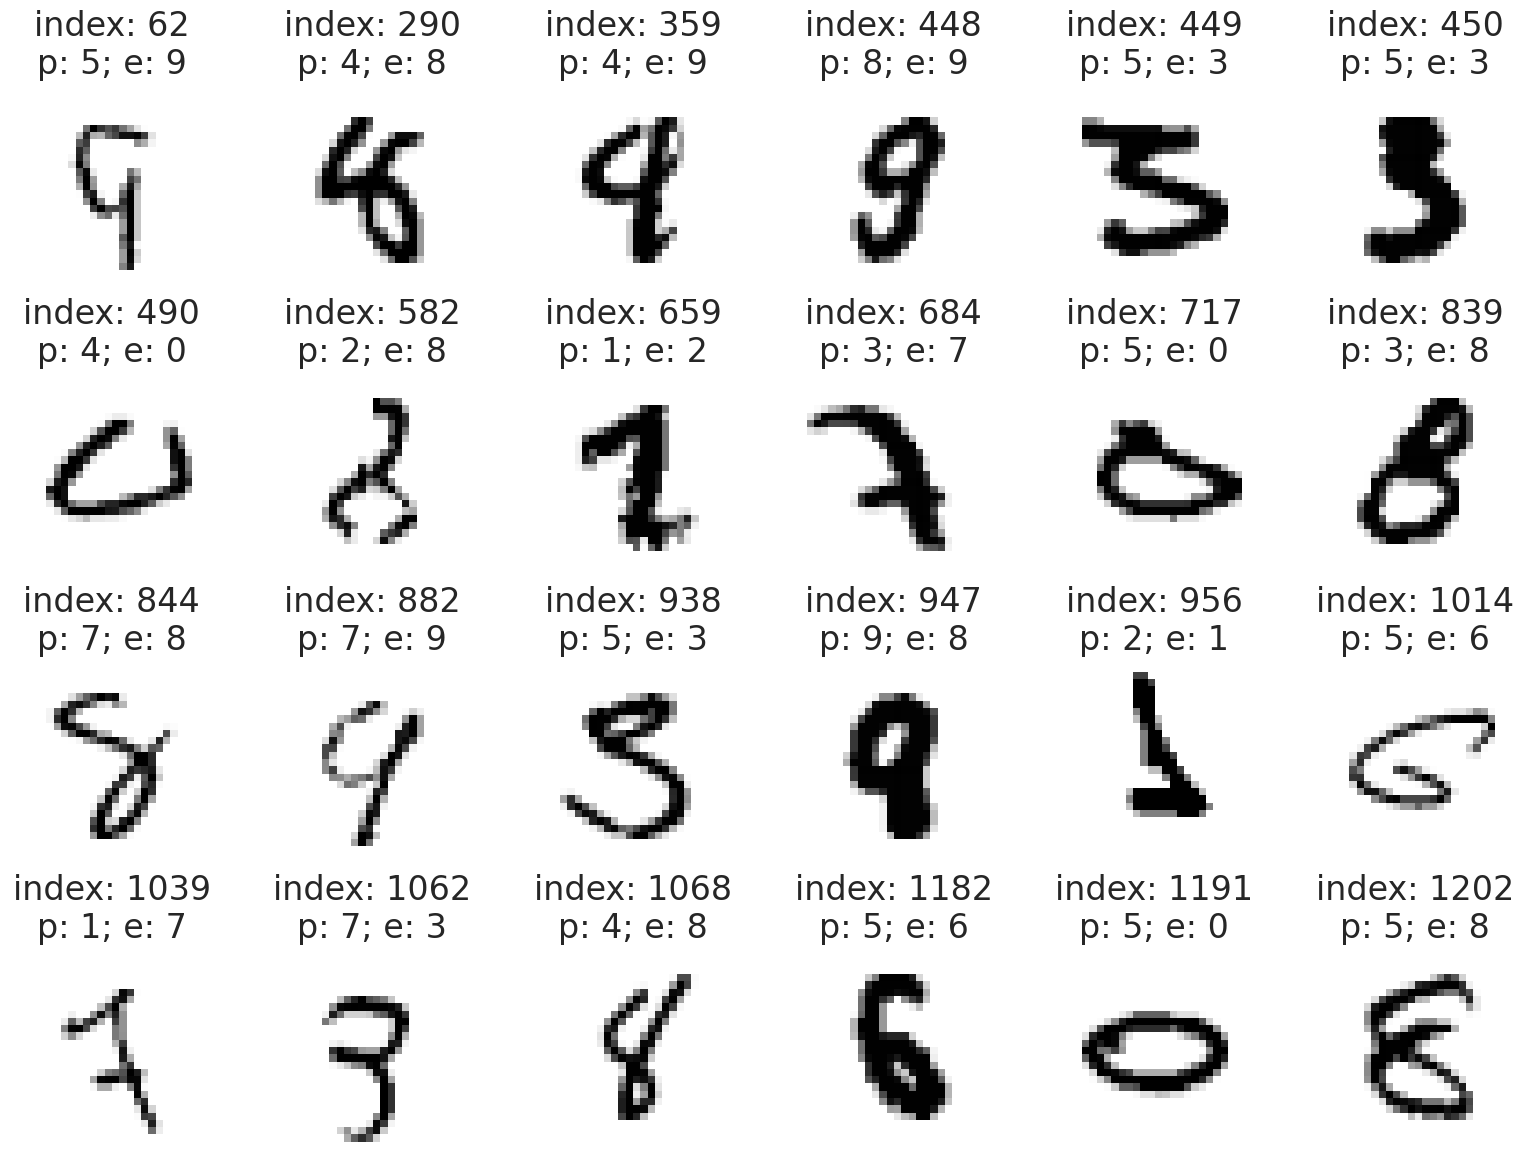

In [ ]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 12))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])  # remove x-axis tick marks
    axes.set_yticks([])  # remove y-axis tick marks
    axes.set_title(f'index: {index}\np: {predicted}; e: {expected}')
plt.tight_layout()

In [ ]:
def display_probabilities(prediction):
    for index, probability in enumerate(prediction):
        print(f'{index}: {probability:.10%}')

In [ ]:
display_probabilities(predictions[495])

0: 0.5487416871%
1: 0.0000018059%
2: 44.1036164761%
3: 0.0343395746%
4: 0.0097252552%
5: 0.0000434945%
6: 0.0899642764%
7: 0.0000000141%
8: 55.2132844925%
9: 0.0002833939%


In [ ]:
display_probabilities(predictions[583])

0: 0.0000000367%
1: 0.0000005965%
2: 87.7977252007%
3: 7.7220559120%
4: 0.0000000051%
5: 0.0000006961%
6: 0.0000000007%
7: 3.4501131624%
8: 1.0300995782%
9: 0.0000009882%


In [ ]:
display_probabilities(predictions[625])

0: 0.0000188214%
1: 0.0000000898%
2: 0.2348633017%
3: 0.0000000002%
4: 47.6841032505%
5: 0.0000022249%
6: 52.0810186863%
7: 0.0000000342%
8: 0.0000004685%
9: 0.0000025736%


In [ ]:
cnn.save('mnist_cnn.h5')

In [ ]:
##########################################################################
# (C) Copyright 2019 by Deitel & Associates, Inc. and                    #
# Pearson Education, Inc. All Rights Reserved.                           #
#                                                                        #
# DISCLAIMER: The authors and publisher of this book have used their     #
# best efforts in preparing the book. These efforts include the          #
# development, research, and testing of the theories and programs        #
# to determine their effectiveness. The authors and publisher make       #
# no warranty of any kind, expressed or implied, with regard to these    #
# programs or to the documentation contained in these books. The authors #
# and publisher shall not be liable in any event for incidental or       #
# consequential damages in connection with, or arising out of, the       #
# furnishing, performance, or use of these programs.                     #
##########################################################################